In [2]:
import pandas as pd

file_path = "ENSAE_Historical_FX.xlsx"
sheets = ["Advanced", "Emerging", "Frontier"]

all_data = []

for sheet in sheets:
    
    df_raw = pd.read_excel(file_path, sheet_name=sheet, header=None)
    
    for i in range(0, df_raw.shape[1], 3):
        
        if i + 1 >= df_raw.shape[1]:
            continue
        
        country_name = df_raw.iloc[0, i+1]
        
        if pd.isna(country_name):
            continue
        
        country_name = str(country_name).strip()
        
        dates = pd.to_datetime(df_raw.iloc[8:, i], errors="coerce")
        values = df_raw.iloc[8:, i+1]
        
        temp = pd.DataFrame({
            "Date": dates,
            "Country": country_name,
            "Category": sheet,
            "FX": values
        })
        
        temp = temp.dropna(subset=["Date"])
        all_data.append(temp)

# Format long
df_long = pd.concat(all_data, ignore_index=True)

# Format WIDE avec MultiIndex colonnes
df_wide = df_long.pivot_table(
    index="Date",
    columns=["Country", "Category"],
    values="FX",
    aggfunc="first"
).sort_index()

# ✅ Export Excel
df_wide.to_excel("FX_wide_with_category.xlsx")

print("Fichier créé : FX_wide_with_category.xlsx")


Fichier créé : FX_wide_with_category.xlsx


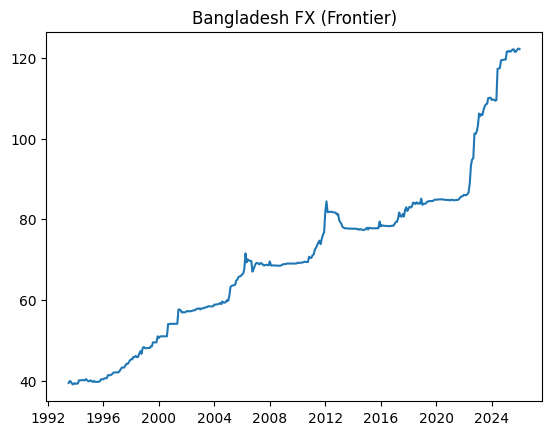

In [3]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

# Lire le fichier avec double header
df = pd.read_excel(
    "FX_wide_with_category.xlsx",
    index_col=0,
    header=[0, 1]   # 🔴 important
)

df.index = pd.to_datetime(df.index)

# Sélection du pays (Country, Category)
plt.plot(df.index, df[("Bangladesh", "Frontier")])
plt.title("Bangladesh FX (Frontier)")
plt.show()

In [4]:
import pandas as pd
import numpy as np

# Remplacer les 0 par NaN
df_clean = df.replace(0, np.nan)

# Calcul des moments (NaN ignorés automatiquement)
mean_fx = df_clean.mean()
var_fx = df_clean.var()

# Créer le tableau final
moments = pd.DataFrame({
    "Mean (Moment 1)": mean_fx,
    "Variance (Moment 2 - centered)": var_fx
})

# Supprimer les pays qui seraient entièrement NaN
moments = moments.dropna()

# Trier par variance décroissante
moments_sorted = moments.sort_values(
    by="Variance (Moment 2 - centered)",
    ascending=False
)

moments_sorted



,,Mean (Moment 1),Variance (Moment 2 - centered)
Country,Category,,
Lao PDR,Frontier,8401.204450,2.577689e+07
Vietnam,Frontier,18322.483376,2.122134e+07
Indonesia,Emerging,9825.217073,1.863434e+07
Colombia,Emerging,2404.003142,1.036658e+06
Myanmar,Frontier,656.866267,6.251153e+05
Nigeria,Frontier,306.846071,1.326480e+05
South Korea,Emerging,1027.545959,4.781363e+04
Chile,Emerging,525.451328,4.648959e+04
Kazakhstan,Frontier,222.502720,1.997741e+04


In [5]:
# Nettoyage : enlever 0 et NaN
df_clean = df.replace(0, np.nan)

# Statistiques descriptives
desc_levels = df_clean.describe()

# Ajouter skewness et kurtosis
desc_levels.loc["skew"] = df_clean.skew()
desc_levels.loc["kurtosis"] = df_clean.kurtosis()

desc_levels

Country,Australia,Bangladesh,Botswana,Brazil,Brunei,Buthan,Canada,Chile,China,Colombia,...,Sri Lanka,Sweden,Switzerland,Taiwan,Thailand,Trinidad & Tobago,Tunisia,Turkey,UK,Vietnam
Category,Advanced,Frontier,Frontier,Emerging,Frontier,Frontier,Advanced,Emerging,Emerging,Emerging,...,Frontier,Advanced,Advanced,Emerging,Emerging,Frontier,Frontier,Emerging,Advanced,Frontier
count,649.000000,391.000000,398.000000,408.000000,391.000000,636.000000,649.000000,497.000000,540.000000,401.000000,...,636.000000,649.000000,649.000000,507.000000,540.000000,391.000000,621.000000,539.000000,649.000000,391.000000
mean,0.845172,70.697893,0.169761,2.636415,1.467011,38.325969,1.238379,525.451328,6.282303,2404.003142,...,92.156682,7.210824,1.522321,31.022211,31.646435,6.357688,1.365243,3.864878,1.665042,18322.483376
std,0.219026,20.777266,0.091942,1.560004,0.169413,24.282478,0.159103,215.614451,1.973864,1018.164243,...,82.421178,1.814149,0.648058,3.448956,6.174409,0.323660,0.804721,8.409697,0.319056,4606.662090
min,0.485600,39.064600,0.069700,0.000500,1.202300,7.270000,0.945100,38.960000,1.588600,691.680000,...,6.060000,3.898600,0.785600,24.620000,20.650000,5.429900,0.383000,0.000100,1.079000,10536.000000
25%,0.701200,56.950000,0.094800,1.710500,1.347150,12.547500,1.122000,410.730000,5.474000,1810.400000,...,27.832500,6.077500,0.993100,28.658500,25.620000,6.176400,0.830600,0.006650,1.451500,14971.000000
50%,0.767300,69.265000,0.149200,2.246500,1.406700,41.945000,1.246000,524.550000,6.778350,2284.510000,...,71.380000,7.251900,1.374300,30.803000,31.815000,6.321100,1.195400,1.329600,1.607600,17841.000000
75%,0.960400,82.815000,0.212475,3.613825,1.619700,54.268750,1.357700,663.900000,8.276400,3006.780000,...,128.545000,8.466100,1.715700,32.817500,35.593000,6.737250,1.583600,2.239700,1.821100,22733.000000
max,1.487500,122.339800,0.449500,6.173600,1.850500,89.876300,1.604600,996.490000,8.721700,4931.880000,...,368.180000,11.168500,3.914700,40.510000,53.750000,6.914100,3.265400,42.956900,2.616300,26425.000000
skew,1.018527,0.513900,1.226358,0.469848,0.600738,0.278725,0.006833,-0.192118,-0.933994,0.331128,...,1.462170,0.016340,1.494863,0.650550,0.369565,-0.382184,0.950753,3.130085,0.925078,-0.114870


ADVANCED

In [6]:
import pandas as pd

# Lire le fichier avec double header
df = pd.read_excel(
    "FX_wide_with_category.xlsx",
    index_col=0,
    header=[0, 1]
)

df.index = pd.to_datetime(df.index)

# Nettoyer espaces éventuels
df.columns = pd.MultiIndex.from_tuples(
    [(str(c[0]).strip(), str(c[1]).strip()) for c in df.columns]
)

# Sélectionner uniquement les Advanced
df_advanced = df.xs("Advanced", level=1, axis=1)

# Enlever les 0 éventuels
df_advanced = df_advanced.replace(0, pd.NA)

# Calcul moments
mean_adv = df_advanced.mean()
var_adv = df_advanced.var()

# Tableau final
moments_advanced = pd.DataFrame({
    "Mean": mean_adv,
    "Variance": var_adv
}).sort_values(by="Variance", ascending=False)

moments_advanced

,Mean,Variance
Japan,153.108213,4263.819917
Sweden,7.210824,3.291137
Norway,7.078393,2.235579
Denmark,6.609345,1.384794
Switzerland,1.522321,0.419979
UK,1.665042,0.101796
Singapore,1.612675,0.086967
Australia,0.845172,0.047972
Euro Area,1.177739,0.028554
Canada,1.238379,0.025314


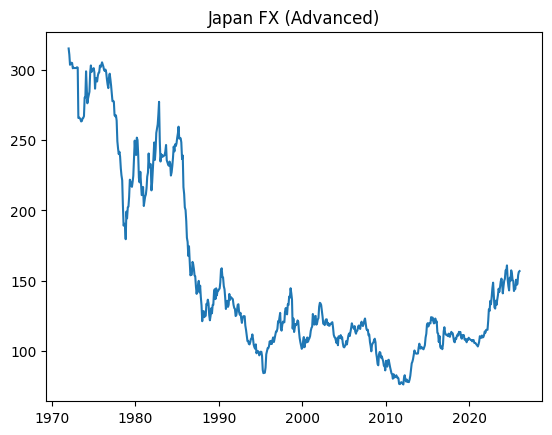

In [7]:
plt.plot(df.index, df[("Japan", "Advanced")])
plt.title("Japan FX (Advanced)")
plt.show()

In [8]:
import numpy as np

returns = np.log(df_advanced).diff()
returns.var().sort_values(ascending=False)

Switzerland    0.001085
Australia      0.001010
Japan          0.000985
Sweden         0.000967
Norway         0.000953
Denmark        0.000883
Euro Area      0.000834
UK             0.000786
Canada         0.000374
Singapore      0.000233
dtype: float64

In [15]:
import numpy as np

# Calcul rendements log
returns_eme = np.log(df_advanced).diff()

# Volatilité (écart-type)
vol_eme = returns_eme.std()

# Variance des rendements
var_eme = returns_eme.var()

moments_emerging = pd.DataFrame({
    "Mean Return": returns_eme.mean(),
    "Volatility (Std)": vol_eme,
    "Variance of Returns": var_eme
}).sort_values(by="Volatility (Std)", ascending=False)

moments_emerging

,Mean Return,Volatility (Std),Variance of Returns
Switzerland,-0.002463,0.032935,0.001085
Australia,-0.000891,0.031773,0.001010
Japan,-0.001076,0.031377,0.000985
Sweden,0.000988,0.031104,0.000967
Norway,0.000629,0.030873,0.000953
Denmark,-0.000162,0.029716,0.000883
Euro Area,-0.000226,0.028883,0.000834
UK,-0.000988,0.028042,0.000786
Canada,0.000484,0.019346,0.000374
Singapore,-0.000886,0.015278,0.000233


In [9]:
import pandas as pd
import numpy as np
from scipy.stats import jarque_bera

# Charger le fichier avec MultiIndex colonnes
df = pd.read_excel(
    "FX_wide_with_category.xlsx",
    index_col=0,
    header=[0, 1]
)

df.index = pd.to_datetime(df.index)

# Nettoyer les noms
df.columns = pd.MultiIndex.from_tuples(
    [(str(c[0]).strip(), str(c[1]).strip()) for c in df.columns]
)

# Sélectionner uniquement les Advanced
df_advanced = df.xs("Advanced", level=1, axis=1)

# Remplacer les 0 éventuels
df_advanced = df_advanced.replace(0, np.nan)

# Calcul des rendements log
returns = np.log(df_advanced).diff()

results = []

for country in returns.columns:
    
    series = returns[country].dropna()
    
    if len(series) > 0:
        jb_stat, jb_pvalue = jarque_bera(series)
        
        results.append({
            "Country": country,
            "JB Statistic": jb_stat,
            "p-value": jb_pvalue
        })

jb_results = pd.DataFrame(results).set_index("Country")

# Trier par p-value croissante
jb_results = jb_results.sort_values("p-value")

jb_results

,JB Statistic,p-value
Country,,
Canada,823.825470,1.284021e-179
Australia,644.372817,1.191848e-140
Sweden,242.279592,2.452759e-53
Singapore,163.151586,3.733217e-36
UK,111.215113,7.078564e-25
Japan,111.124418,7.406947e-25
Switzerland,69.149654,9.645913e-16
Norway,41.200512,1.130896e-09
Denmark,30.641576,2.219557e-07


In [10]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro

# Charger le fichier avec MultiIndex colonnes
df = pd.read_excel(
    "FX_wide_with_category.xlsx",
    index_col=0,
    header=[0, 1]
)

df.index = pd.to_datetime(df.index)

# Nettoyer éventuels espaces
df.columns = pd.MultiIndex.from_tuples(
    [(str(c[0]).strip(), str(c[1]).strip()) for c in df.columns]
)

# Sélectionner uniquement les pays Advanced
df_advanced = df.xs("Advanced", level=1, axis=1)

# Remplacer 0 éventuels
df_advanced = df_advanced.replace(0, np.nan)

# Calcul des rendements log
returns = np.log(df_advanced).diff()

results = []

for country in returns.columns:
    
    series = returns[country].dropna()
    
    # ⚠️ Shapiro ne fonctionne pas bien avec trop d'observations (>5000)
    # On peut limiter à 5000 observations si nécessaire
    if len(series) > 5000:
        series = series.sample(5000, random_state=42)
    
    if len(series) > 3:  # minimum requis
        stat, p_value = shapiro(series)
        
        results.append({
            "Country": country,
            "Shapiro Statistic": stat,
            "p-value": p_value
        })

shapiro_results = pd.DataFrame(results).set_index("Country")

# Trier par p-value croissante
shapiro_results = shapiro_results.sort_values("p-value")

shapiro_results

,Shapiro Statistic,p-value
Country,,
Australia,0.942598,3.969772e-15
Canada,0.948025,2.595329e-14
Sweden,0.972122,9.140402e-10
Singapore,0.973202,2.290925e-08
Japan,0.979298,6.159502e-08
UK,0.981561,2.761411e-07
Norway,0.985326,4.255494e-06
Switzerland,0.985980,7.090525e-06
Denmark,0.988174,4.298607e-05


In [11]:
import numpy as np

returns = np.log(df).diff()

# Séparer groupes
adv = returns.xs("Advanced", level=1, axis=1)
emg = returns.xs("Emerging", level=1, axis=1)
fro = returns.xs("Frontier", level=1, axis=1)


vol_adv = adv.std()
vol_emg = emg.std()
vol_fro = fro.std()

print("Volatilité moyenne Advanced:", vol_adv.mean())
print("Volatilité moyenne Emerging:", vol_emg.mean())
print("Volatilité moyenne Frontier:", vol_fro.mean())

Volatilité moyenne Advanced: 0.02793275212153017
Volatilité moyenne Emerging: 0.03865413149636345
Volatilité moyenne Frontier: 0.043999835856843646


In [12]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
returns = np.log(df_advanced).diff()

results_returns = []

for country in returns.columns:
    
    series = returns[country].dropna()
    
    if len(series) > 20:
        
        adf_stat, p_value, lags, nobs, crit_vals, icbest = adfuller(series)
        
        results_returns.append({
            "Country": country,


            "ADF Statistic": adf_stat,
            "p-value": p_value
        })

adf_returns = pd.DataFrame(results_returns).set_index("Country")

adf_returns.sort_values("p-value")

,ADF Statistic,p-value
Country,,
Australia,-25.282077,0.000000e+00
Euro Area,-24.254207,0.000000e+00
Singapore,-22.339233,0.000000e+00
Norway,-24.916311,0.000000e+00
Sweden,-23.711153,0.000000e+00
Switzerland,-25.219138,0.000000e+00
UK,-23.700105,0.000000e+00
Denmark,-16.746110,1.345787e-29
Japan,-16.433507,2.465732e-29


Emerging

In [13]:
import pandas as pd

# Lire le fichier avec double header
df = pd.read_excel(
    "FX_wide_with_category.xlsx",
    index_col=0,
    header=[0, 1]
)

df.index = pd.to_datetime(df.index)

# Nettoyer espaces éventuels
df.columns = pd.MultiIndex.from_tuples(
    [(str(c[0]).strip(), str(c[1]).strip()) for c in df.columns]
)

# Sélectionner uniquement les Emerging
df_emerging = df.xs("Emerging", level=1, axis=1)

# Enlever les 0 éventuels
df_emerging = df_emerging.replace(0, pd.NA)

# Calcul moments
mean_eme = df_emerging.mean()
var_eme = df_emerging.var()

# Tableau final
moments_emerging = pd.DataFrame({
    "Mean": mean_eme,
    "Variance": var_eme
}).sort_values(by="Variance", ascending=False)

moments_emerging

,Mean,Variance
Indonesia,9825.217073,1.863434e+07
Colombia,2404.003142,1.036658e+06
South Korea,1027.545959,4.781363e+04
Chile,525.451328,4.648959e+04
Hungary,241.035575,4.827078e+03
Russia,39.861818,6.712213e+02
India,38.325969,5.896387e+02
Philippines,44.969929,9.846777e+01
Turkey,3.864878,7.072301e+01
Mexico,8.254521,5.113743e+01


In [14]:
import numpy as np

# Calcul rendements log
returns_eme = np.log(df_emerging).diff()

# Volatilité (écart-type)
vol_eme = returns_eme.std()

# Variance des rendements
var_eme = returns_eme.var()

moments_emerging = pd.DataFrame({
    "Mean Return": returns_eme.mean(),
    "Volatility (Std)": vol_eme,
    "Variance of Returns": var_eme
}).sort_values(by="Volatility (Std)", ascending=False)

moments_emerging

,Mean Return,Volatility (Std),Variance of Returns
Brazil,0.022862,0.085745,0.007352
Mexico,0.011224,0.070213,0.004930
Indonesia,0.005211,0.065937,0.004348
Turkey,0.024109,0.061648,0.003800
Russia,0.011270,0.059780,0.003574
South Africa,0.004742,0.041159,0.001694
Hungary,0.003263,0.035663,0.001272
Poland,0.001835,0.035297,0.001246
Colombia,0.004242,0.034799,0.001211
Chile,0.004470,0.032658,0.001067
